In [1]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Convert the whitespace separated result file into a table.
def load_result_dataframe(raw_path=Path('/home/ubuntu/hnswlib/build/result.txt')):
    raw_path = Path(raw_path)
    records = []
    with raw_path.open(encoding='utf-8') as file:
        for line in file:
            columns = line.strip().split()
            # Skip metadata rows by requiring a numeric id and four columns
            if len(columns) == 4 and columns[0].isdigit():
                idx, accu, time_value, time_unit = columns
                records.append(
                    {
                        'idx': int(idx),
                        'accu': float(accu),
                        'time': float(time_value),
                        'time_unit': time_unit,
                    }
                )
    return pd.DataFrame(records)


df = load_result_dataframe()
df.to_csv('/home/ubuntu/hnswlib/build/result.csv', index=False)
df.head()


,idx,accu,time,time_unit
0,1,0.1539,39.2217,us
1,2,0.2531,33.8308,us
2,3,0.3323,43.8011,us
3,4,0.3911,51.3585,us
4,5,0.4375,55.6140,us


In [3]:
RAW_DEFAULT_PATH = '/home/ubuntu/hnswlib/build/default.txt'
RAW_START_PATH = '/home/ubuntu/hnswlib/build/start.txt'
RAW_RESULT_PATH = '/home/ubuntu/hnswlib/build/result.txt'


default_df = load_result_dataframe(RAW_DEFAULT_PATH)
start_df = load_result_dataframe(RAW_START_PATH)
result_df = load_result_dataframe(RAW_RESULT_PATH)



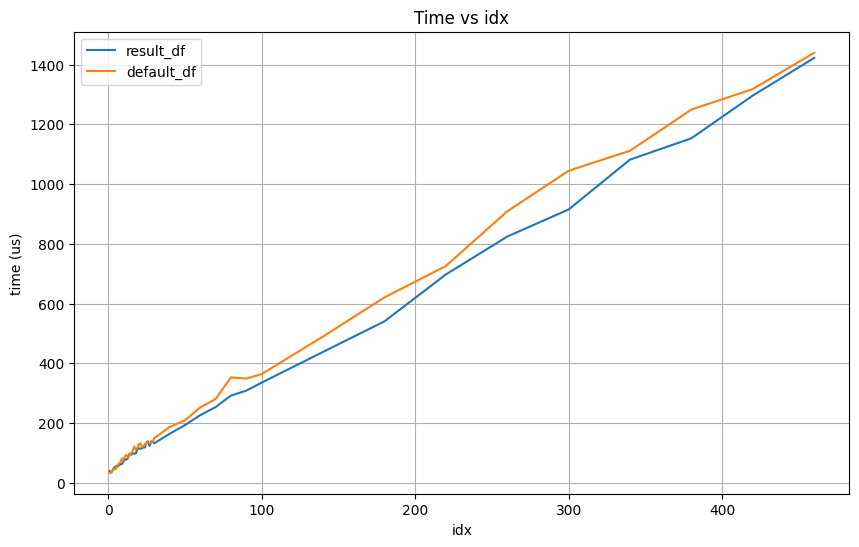

In [ ]:


plt.figure(figsize=(10, 6))
plt.plot(result_df['idx'], result_df['time'], label='result_df')
plt.plot(default_df['idx'], default_df['time'], label='default_df')
plt.xlabel('idx')
plt.ylabel('time (us)')
plt.title('Time vs idx')
plt.legend()
plt.grid(True)
plt.show()
